In [2]:
import sys
sys.path.append("..")
from utils import *

---

## Moyenne de deux vecteurs

On divise par 3 car on a 3 vecteurs.

In [4]:
cache_l1 = int(round(512/(3*16),0))
cache_l2 = int(round(16_000/(3*16),0))
cache_l3 = int(round(22_000/(3*2),0))

caches_core = {
    "L1": cache_l1,
    "L2": cache_l2,
    "L3": cache_l3,
    "L3 × 2": 2*cache_l3,
}

caches_full = caches_core.copy()


# Ajoute les multiples pairs de L1 et L2 jusqu'à 16
for i in range(2, 17, 2):
    caches_full[f"L1 × {i}"] = cache_l1 * i
    caches_full[f"L2 × {i}"] = cache_l2 * i

## Moyenne de deux vecteurs

### Q1

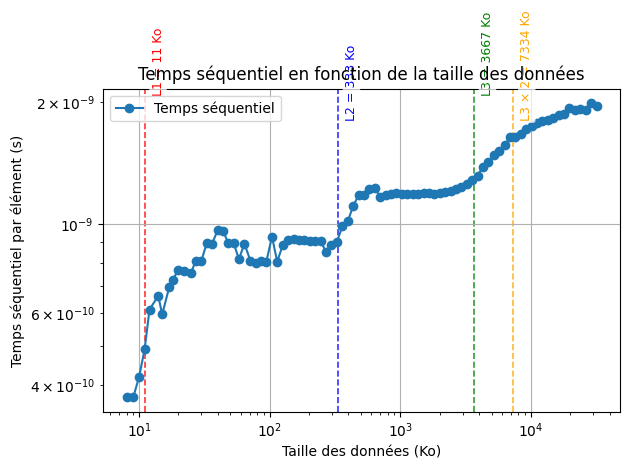

In [6]:
path="results/resultats.txt"
afficher_temps_sequentiel_vs_taille(path, caches_core)

Passe sur deux cpu implique 2 cache L3. On voir le shift

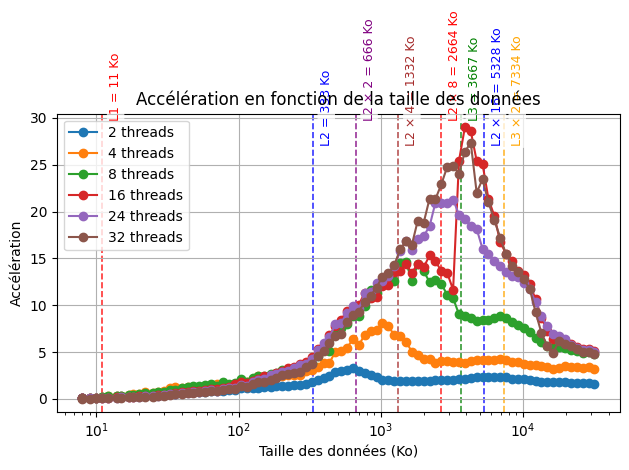

In [15]:
path="results/resultats.txt"
caches = caches_core.copy()

# Ajoute les multiples pairs de L1 et L2 jusqu'à 16
for i in [2,4,8,16]:
    caches[f"L2 × {i}"] = cache_l2 * i
afficher_acceleration_toutes_tailles(path, threads=[2,4,8,16,24,32], caches=caches)

temps perdu par context switch entre 16 et 32 

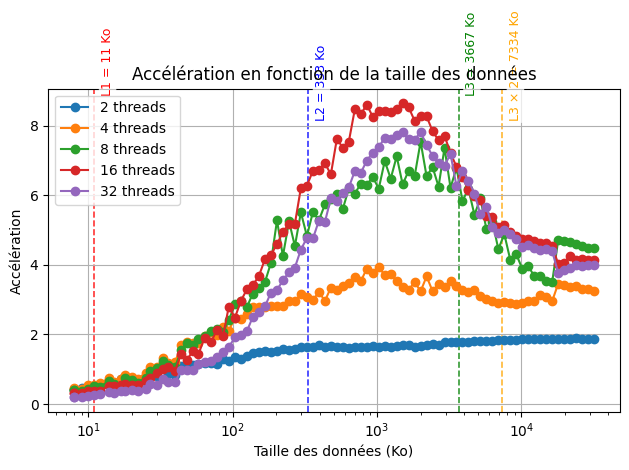

In [18]:
path="results/resultats_cf.txt"
afficher_acceleration_toutes_tailles(path, threads=[2,4,8,16,32], caches=caches_core)

### Q2

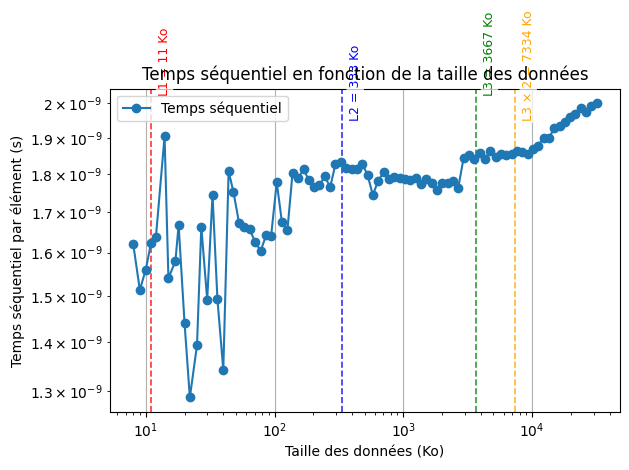

In [20]:
path="results/resultats_cf.txt"
afficher_temps_sequentiel_vs_taille(path, caches=caches_core)

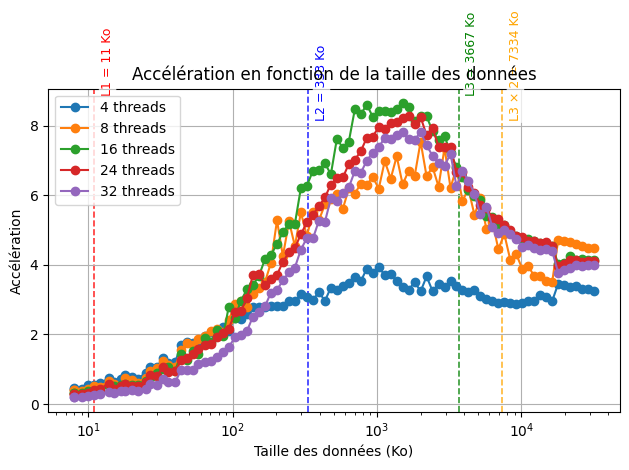

In [23]:
path="results/resultats_cf.txt"
afficher_acceleration_toutes_tailles(path, threads=[4,8,16,24, 32], caches=caches_core)

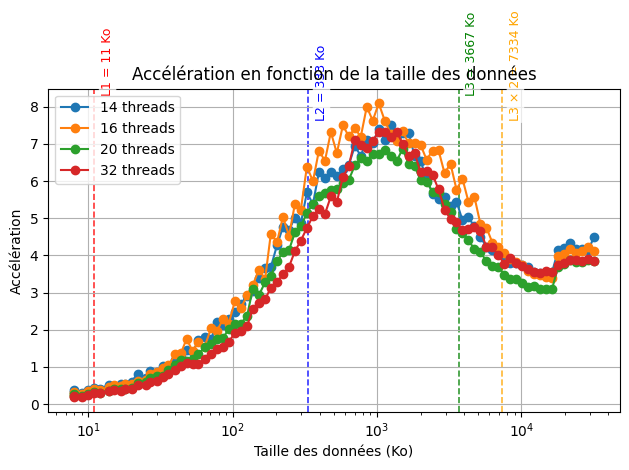

In [26]:
path="results/resultats_cf_02.txt"
afficher_acceleration_toutes_tailles(path, threads=[14,16,20, 32], caches=caches_core)

## 4 - Produit scalaire

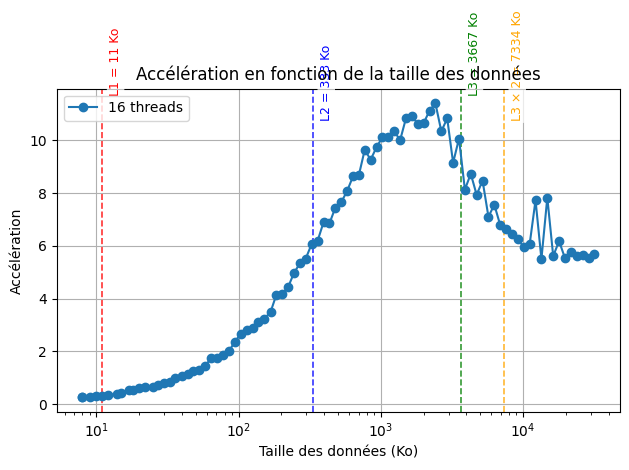

In [30]:
path="results/resultat_partie_04.txt"
afficher_acceleration_toutes_tailles(path, threads=[e for e in range(2,32,8)]+[16,32], caches=caches_core)

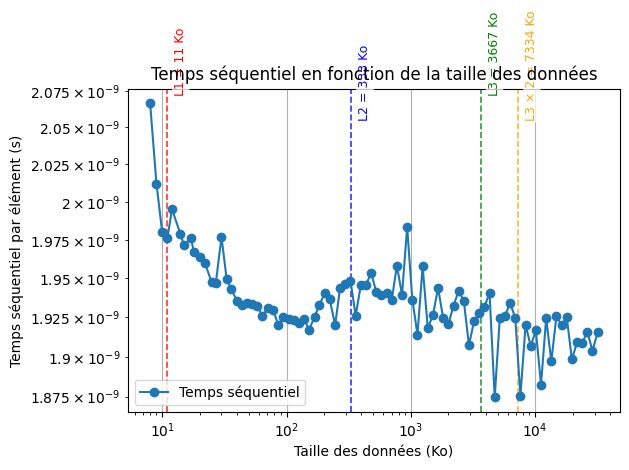

In [31]:
path="results/resultat_partie_04.txt"
afficher_temps_sequentiel_vs_taille(path, caches=caches_core)

## 

---

## Parallélisation d’un tri bubble-sort

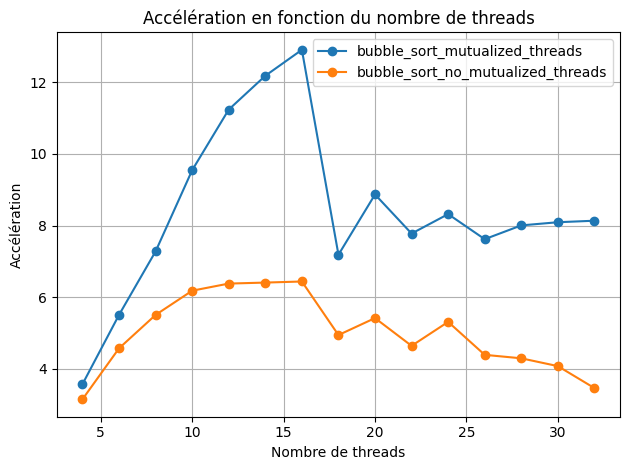

In [13]:
path=["results/bubble_sort_mutualized_threads.txt","results/bubble_sort_no_mutualized_threads.txt"]
afficher_acceleration_vs_coeurs(path)

Implémentation 1 : région parallèle unique (équipe de threads mutualisée).
La région #pragma omp parallel englobe la boucle sur les étapes : l'équipe de threads est créée une seule fois, puis réutilisée à chaque étape de la boucle séquentielle externe. Seule la barrière implicite de fin de #pragma omp for subsiste à chaque étape, ce qui est nécessaire à la correction du tri odd-even (chaque phase dépend de la précédente).

L'accélération croît quasi linéairement avec le nombre de threads jusqu'à 16 threads. Ce point correspond au nombre de cœurs physiques de la machine. Au-delà, l'accélération chute brutalement puis se stabilise de 18 à 32 threads. Cette dégradation s'explique par le recours à l'hyper-threading : deux threads logiques se partagent les unités d'exécution et les caches d'un même cœur. L'algorithme est limité par la bande passante mémoire et la latence des accès en tire peu de bénéfice. S'ajoutent le coût croissant des barrières de synchronisation (en $O(log p)$ ou $O(p)$ selon l'implémentation du runtime) et le déséquilibre possible du nombre d'itérations par thread.

Implémentation 2 : région parallèle recréée à chaque étape.
Ici, #pragma omp parallel est placé à l'intérieur de la boucle sur les étapes : la région parallèle est donc ouverte et fermée N fois. Le surcoût provient plutôt de l'entrée et de la sortie de la région : réveil des threads, distribution du travail, barrière de fin de région. Ce coût est proportionnel au nombre de threads et se paie N fois, soit $N \times p$ « activations » pour $N$ étapes et $p$ threads.

L'accélération progresse entre 4 et 10 threads, plafonne autour de 6,4 entre 10 et 16 threads, puis se dégrade pour atteindre environ 3,5 à 32 threads. Au-delà du plafond, le surcoût de gestion de la région parallèle (qui croît avec $p$) l'emporte sur le gain de parallélisation, le travail par étape étant faible (environ $N/2$ comparaisons réparties sur $p$ threads).

Conclusion.
La mutualisation de la région parallèle double environ l'accélération maximale (13 contre 6,4). Pour les deux versions, le point optimal se situe à 16 threads, soit le nombre de cœurs physiques. Au-delà, l'hyper-threading est contre-productif pour cet algorithme dominé par les accès mémoire.